# Nhận diện Phương tiện Giao thông với Custom CNN
*Phương pháp: Xây dựng mạng Nơ-ron Tích chập từ con số 0 (Train from scratch)*

Cấu trúc dự án bao gồm:
1. Thiết lập & Cấu hình (Setup & Config)
2. Đường ống Dữ liệu (Data Pipeline & Augmentation)
3. Kiến trúc Mô hình (Model Architecture)
4. Động cơ Huấn luyện (Training Engine & Checkpoint)
5. Đánh giá Toàn diện (Evaluation & Metrics)

## 1. Import thư viện

In [2]:
!pip install torchviz

In [3]:
import os
import cv2
import copy
import random
import multiprocessing
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchsummary import summary
from torchviz import make_dot
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset

import warnings
warnings.filterwarnings('ignore') # Ẩn các cảnh báo không cần thiết

print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.10.0+cu128


## 2. Cấu hình Siêu tham số (Hyperparameters)

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

class Config:
    DATA_DIR = '/kaggle/input/datasets/editcadic/bd128-large/bdd_cropped_data (2)'
    SAVE_MODEL_PATH = '/kaggle/working/best_traffic_cnn.pth'
    
    # Training params
    BATCH_SIZE = 32
    IMG_SIZE = 128
    NUM_CLASSES = 5
    NUM_WORKERS = multiprocessing.cpu_count()
    NUM_EPOCHS = 20
    LEARNING_RATE = 0.001
    
    # cuda config
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 
    MEAN = [0.485, 0.456, 0.406]  
    STD = [0.229, 0.224, 0.225]

In [5]:
# Init Config
cfg = Config()
set_seed(42)
print(f"Đang sử dụng thiết bị: {cfg.DEVICE}")

Đang sử dụng thiết bị: cuda


## 3. Data Pipeline & Augmentation

In [7]:
# Data Augumentation for Train
train_transforms = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomEqualize(p=0.2),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0),
    transforms.Normalize(mean=cfg.MEAN, std=cfg.STD)
])

# Tập val va test
val_test_transforms = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=cfg.MEAN, std=cfg.STD)
])

In [ ]:
val_split = 0.2

train_dir = os.path.join(cfg.DATA_DIR, 'train')
full_train_dataset_aug = datasets.ImageFolder(train_dir, transform=train_transforms)
full_train_dataset_no_aug = datasets.ImageFolder(train_dir, transform=val_test_transforms)
class_names = full_train_dataset_aug.classes

num_train = len(full_train_dataset_aug)
indices = list(range(num_train))
np.random.shuffle(indices)
split_idx = int(np.floor(val_split * num_train))

train_idx, val_idx = indices[split_idx:], indices[:split_idx]

# Tạo Subset
train_dataset = Subset(full_train_dataset_aug, train_idx)
val_dataset = Subset(full_train_dataset_no_aug, val_idx)

test_dir = os.path.join(cfg.DATA_DIR, 'val')
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

train_loader = DataLoader(
    train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True, 
    num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=True
)

val_loader = DataLoader(
    val_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, 
    num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=False
)

test_loader = DataLoader(
    test_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, 
    num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=False
)

In [ ]:
print(f"Các lớp phát hiện: {class_names}")

In [8]:
(len(train_loader)  * cfg.BATCH_SIZE, len(val_loader) * cfg.BATCH_SIZE, len(test_loader)  * cfg.BATCH_SIZE)

(59200, 14816, 31808)

In [9]:
num_classes = len(class_names)

img_path_by_classes = {i: [] for i in range(num_classes)}
for path, label in full_train_dataset_no_aug.samples:
        img_path_by_classes[label].append(path)

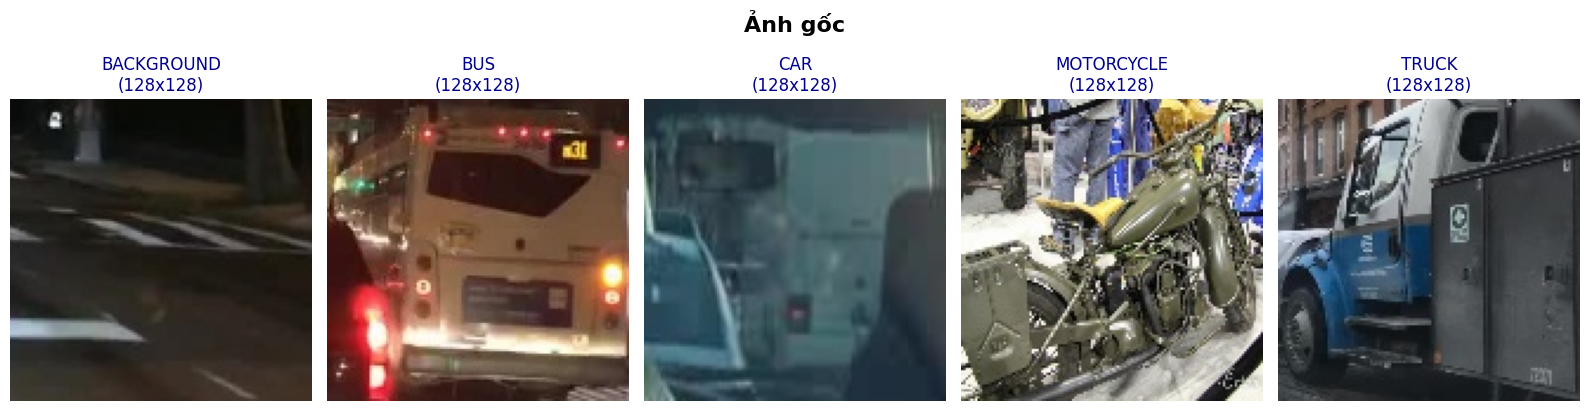

In [10]:
fig, axes = plt.subplots(1, num_classes, figsize=(16, 4))
fig.suptitle("Ảnh gốc", fontsize=16, fontweight='bold', y=1.05)

if num_classes == 1:
    axes = [axes]
    
for i, class_name in enumerate(class_names):
    random_path = random.choice(img_path_by_classes[i])
    
    img = cv2.imread(random_path)
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
        h, w, _ = img_rgb.shape
        axes[i].set_title(f"{class_name.upper()}\n({w}x{h})", fontsize=12, color='darkblue')
        axes[i].axis('off') # Tắt viền tọa độ
    else:
        axes[i].set_title(f"Lỗi đọc ảnh\n{class_name}", color='red')
        axes[i].axis('off')
        
plt.tight_layout()
plt.show()

In [11]:
def denormalize(image_tensor):
    img = image_tensor.numpy().transpose((1, 2, 0))
    img = np.clip(cfg.STD * img + cfg.MEAN, 0, 1)

    return img

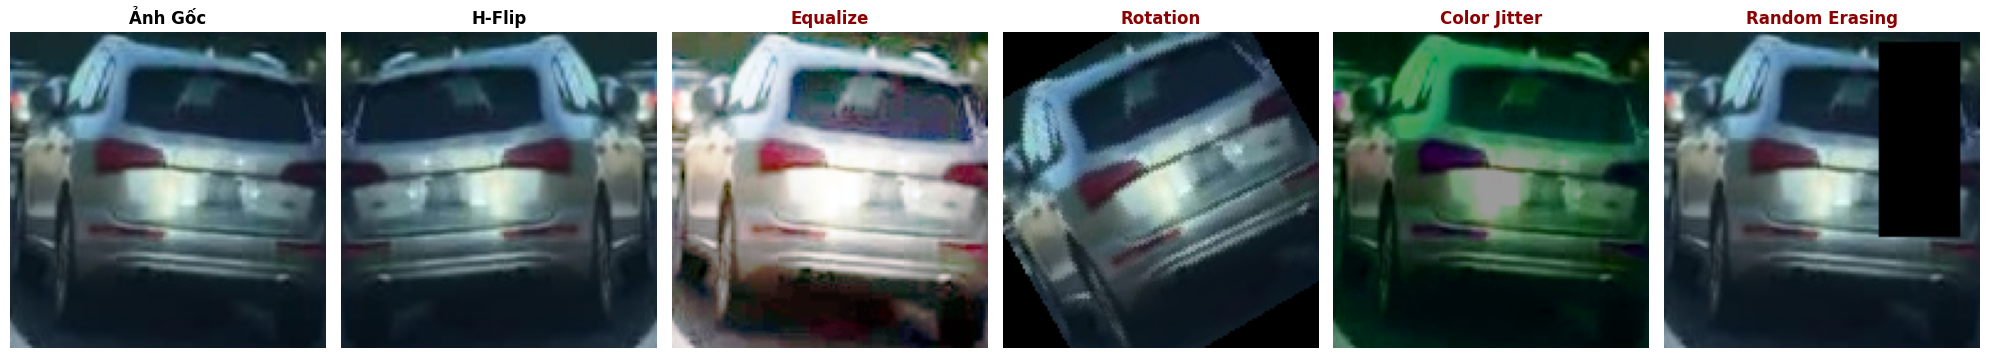

In [12]:
img_path = random.choice(img_path_by_classes[2])
img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
img = Image.fromarray(img)

aug_dict = {
        "Ảnh Gốc": None,
        "H-Flip": transforms.RandomHorizontalFlip(p=1.0),
        "Equalize": transforms.RandomEqualize(p=1.0),
        "Rotation": transforms.RandomRotation(degrees=(30, 30)),
        "Color Jitter": transforms.ColorJitter(brightness=0.8, contrast=0.8, saturation=0.8, hue=0.2), 
        "Random Erasing": transforms.Compose([
            transforms.ToTensor(),
            transforms.RandomErasing(p=1.0, scale=(0.1, 0.2), ratio=(0.3, 3.3), value=0),
            transforms.ToPILImage()
        ])
    }

num_augs = len(aug_dict)

base_img = transforms.Resize(cfg.IMG_SIZE)(img)

fig , axes = plt.subplots(1, num_augs, figsize=(20, 4))
for i, (name, transform) in enumerate(aug_dict.items()):
    if name == "Ảnh Gốc":
        display_img = img
    else:
        display_img = transform(base_img)

    axes[i].imshow(display_img)
    
    title_color = 'black' if i <= 1 else 'darkred'
    axes[i].set_title(name, fontsize=12, color=title_color, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 4. Kiến trúc Mạng CNN (Custom 3-Block Architecture)

In [13]:
class TrafficNet(nn.Module):
    def __init__(self, num_classes=5):
        super(TrafficNet, self).__init__()
        
        # Layer 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Layer 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Layer 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)

        # Layer 4
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool4 = nn.MaxPool2d(2, 2)
        
        # Classifier layer
        self.flatten_dim = 128 * 8 * 8
        self.fc1 = nn.Linear(self.flatten_dim, 256)
        self.bn_fc = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1) 
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Khởi tạo mô hình
model = TrafficNet(num_classes=cfg.NUM_CLASSES).to(cfg.DEVICE)

In [14]:
model

TrafficNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilat

In [15]:
summary(model, input_size=(3, 128, 128), device=cfg.DEVICE.type)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
         MaxPool2d-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
       BatchNorm2d-5           [-1, 64, 64, 64]             128
         MaxPool2d-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
       BatchNorm2d-8          [-1, 128, 32, 32]             256
         MaxPool2d-9          [-1, 128, 16, 16]               0
           Conv2d-10          [-1, 128, 16, 16]         147,584
      BatchNorm2d-11          [-1, 128, 16, 16]             256
        MaxPool2d-12            [-1, 128, 8, 8]               0
           Linear-13                  [-1, 256]       2,097,408
      BatchNorm1d-14                  [

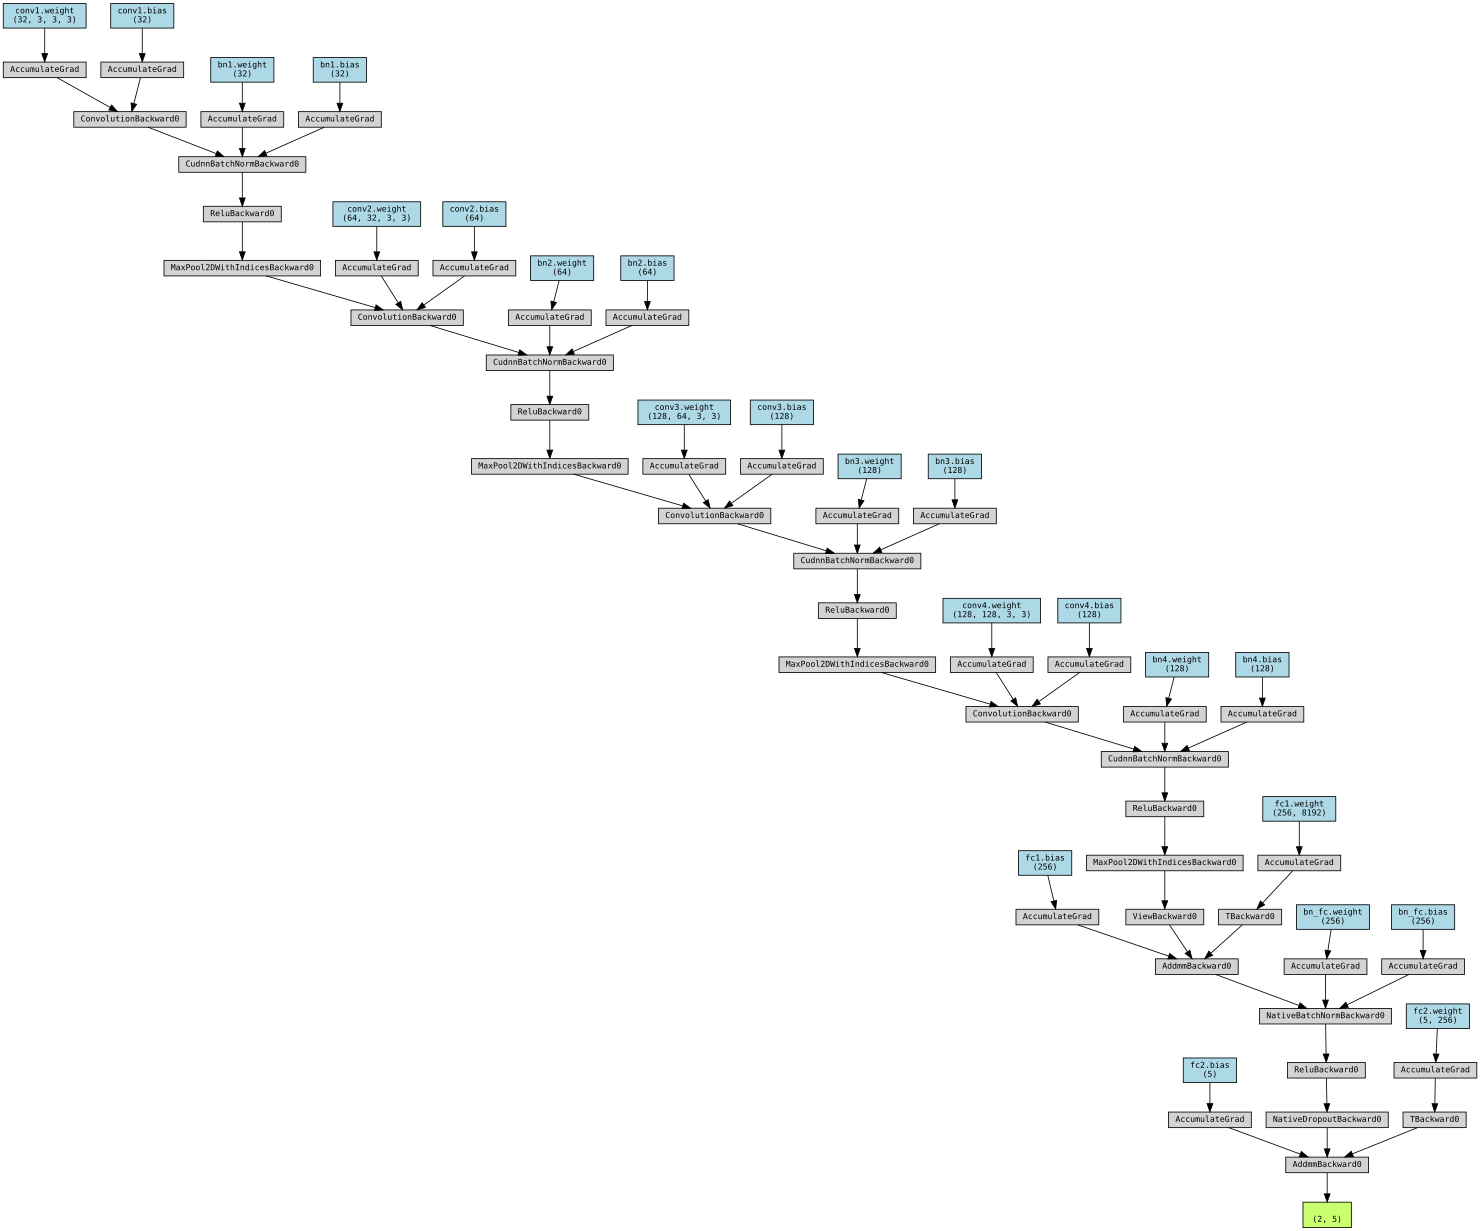

In [16]:
x = torch.randn(2, 3, cfg.IMG_SIZE, cfg.IMG_SIZE).to(cfg.DEVICE)
y = model(x)
make_dot(y, params=dict(list(model.named_parameters()) + [('input', x)]))

## 5. Động cơ Huấn luyện (Training Engine)

In [17]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, config):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    
    print(f"Bắt đầu huấn luyện {config.NUM_EPOCHS} Epochs...")
    
    for epoch in range(config.NUM_EPOCHS):
        # --- TRAIN ---
        model.train()
        running_loss, running_corrects = 0.0, 0
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            print(f"\r  [Train] Batch {batch_idx + 1:03d}/{len(train_loader)} | Loss: {loss.item():.4f}", end="", flush=True)

        print()
        
        scheduler.step()
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        
        # --- VALIDATION ---
        model.eval()
        val_loss, val_corrects = 0.0, 0
        with torch.no_grad():
            for batch_idx, (inputs, labels) in enumerate(val_loader):
                inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

                print(f"\r  [Val]   Batch {batch_idx + 1:03d}/{len(val_loader)}", end="", flush=True)

        print()
                
        val_epoch_loss = val_loss / len(val_loader.dataset)
        val_epoch_acc = val_corrects.double() / len(val_loader.dataset)
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())
        history['val_loss'].append(val_epoch_loss)
        history['val_acc'].append(val_epoch_acc.item())
        
        print(f"Epoch {epoch+1:02d}/{config.NUM_EPOCHS} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}")
        
        # --- MODEL CHECKPOINT ---
        if val_epoch_acc > best_val_acc:
            best_val_acc = val_epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), config.SAVE_MODEL_PATH)
            
    print(f"\nHuấn luyện hoàn tất! Kỷ lục Val Acc: {best_val_acc:.4f}")
    # Nạp lại trọng số đỉnh cao nhất trước khi kết thúc hàm
    model.load_state_dict(best_model_wts)
    return history, model

## 6. Đánh giá Hệ thống (Evaluation & Metrics)

In [18]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    epochs = range(1, len(history['train_loss']) + 1)
    
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    ax1.plot(epochs, history['val_loss'], 'r--', label='Val Loss')
    ax1.set_title('Cross-Entropy Loss')
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.7)
    
    ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    ax2.plot(epochs, history['val_acc'], 'r--', label='Val Acc')
    ax2.set_title('Accuracy')
    ax2.legend()
    ax2.grid(True, linestyle=':', alpha=0.7)
    
    plt.show()

In [19]:
def evaluate_comprehensive(model, dataloader, class_names, config):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    print("\n" + "="*50)
    print(" BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT)")
    print("="*50)
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Ma trận Nhầm lẫn (Confusion Matrix)', pad=20)
    plt.ylabel('Thực tế (True Label)')
    plt.xlabel('Dự đoán (Predicted)')
    plt.show()

## Thực thi

In [20]:
# 1. Khởi tạo Loss, Optimizer và Scheduler
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=cfg.LEARNING_RATE)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.NUM_EPOCHS, eta_min=1e-6)

In [21]:
# 2. Bắt đầu Huấn luyện
history, best_model = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, cfg
)

Bắt đầu huấn luyện 20 Epochs...
  [Train] Batch 1850/1850 | Loss: 0.6590
  [Val]   Batch 463/463
Epoch 01/20 | Train Loss: 0.8191 Acc: 0.8036 | Val Loss: 0.6716 Acc: 0.8703
  [Train] Batch 1850/1850 | Loss: 0.6139
  [Val]   Batch 463/463
Epoch 02/20 | Train Loss: 0.7130 Acc: 0.8548 | Val Loss: 0.6337 Acc: 0.8889
  [Train] Batch 1850/1850 | Loss: 0.7516
  [Val]   Batch 463/463
Epoch 03/20 | Train Loss: 0.6796 Acc: 0.8713 | Val Loss: 0.6140 Acc: 0.8994
  [Train] Batch 1850/1850 | Loss: 0.6618
  [Val]   Batch 463/463
Epoch 04/20 | Train Loss: 0.6601 Acc: 0.8798 | Val Loss: 0.6075 Acc: 0.8991
  [Train] Batch 1850/1850 | Loss: 0.5851
  [Val]   Batch 463/463
Epoch 05/20 | Train Loss: 0.6398 Acc: 0.8906 | Val Loss: 0.5944 Acc: 0.9084
  [Train] Batch 1850/1850 | Loss: 0.6046
  [Val]   Batch 463/463
Epoch 06/20 | Train Loss: 0.6288 Acc: 0.8970 | Val Loss: 0.5813 Acc: 0.9170
  [Train] Batch 1850/1850 | Loss: 0.5213
  [Val]   Batch 463/463
Epoch 07/20 | Train Loss: 0.6182 Acc: 0.9016 | Val Loss: 

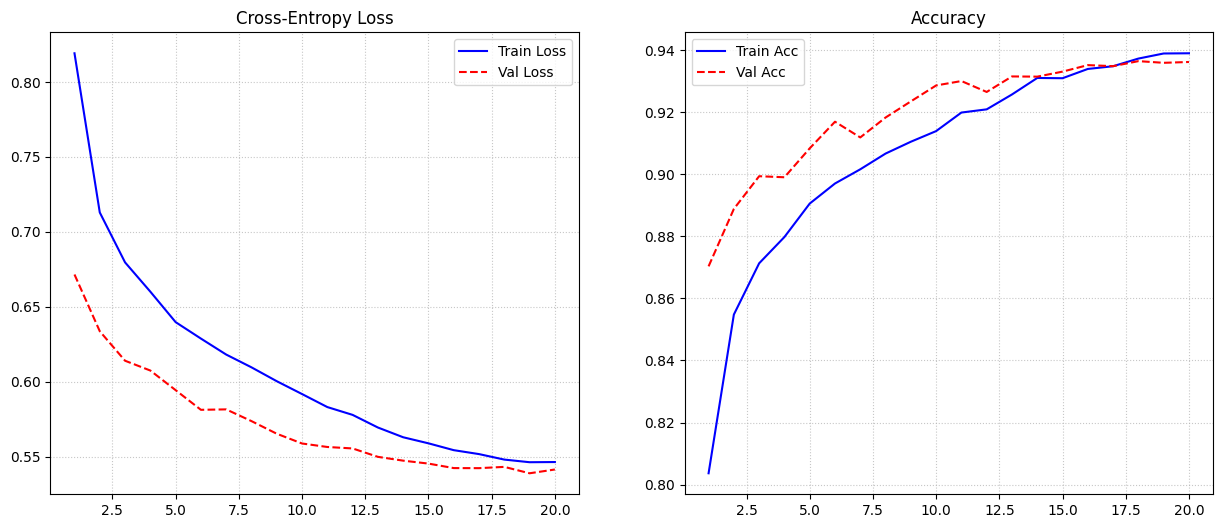

In [22]:
# 3. Vẽ biểu đồ học tập
plot_training_history(history)


 BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT)
              precision    recall  f1-score   support

  background       0.99      0.99      0.99     28605
         bus       0.76      0.82      0.79       939
         car       0.78      0.86      0.82      1000
  motorcycle       0.85      0.99      0.91       264
       truck       0.73      0.71      0.72      1000

    accuracy                           0.97     31808
   macro avg       0.82      0.87      0.84     31808
weighted avg       0.97      0.97      0.97     31808



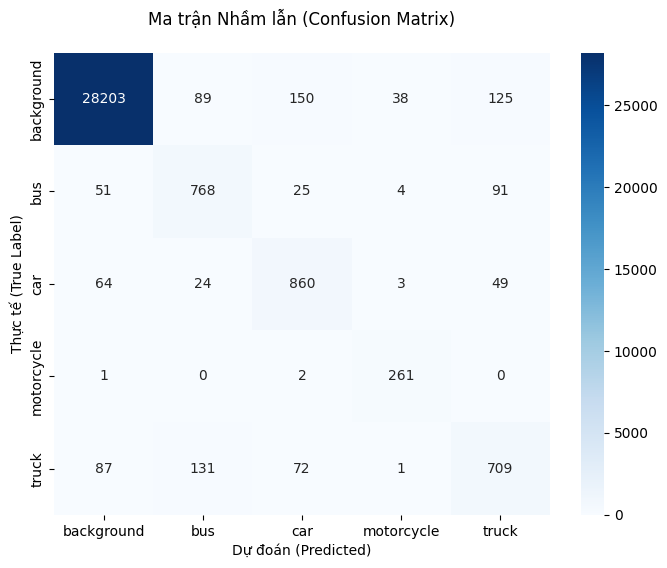

In [23]:
# Đánh giá mô hình
evaluate_comprehensive(best_model, test_loader, class_names, cfg)

In [24]:
import torch
import cv2
from PIL import Image

def predict_image_label(image_path, model, config, class_names):
    # 1. Tiền xử lý ảnh (giống hệt lúc train)
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)), # Ép về kích thước chuẩn của model
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 2. Đọc và chuẩn bị Tensor
    img = cv2.imread(image_path)
    if img is None:
        return "Không tìm thấy ảnh tại đường dẫn này!"
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    input_tensor = transform(img_rgb).unsqueeze(0).to(config.DEVICE)
    
    # 3. Dự đoán
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)
    
    # 4. Trả về kết quả
    label = class_names[predicted_idx.item()]
    score = confidence.item() * 100
    
    print("-" * 30)
    print(f"Đường dẫn: {image_path}")
    print(f"Dự đoán nhãn: {label.upper()}")
    print(f"Độ tự tin: {score:.2f}%")
    print("-" * 30)

# --- THỰC THI ---
# Thay đổi đường dẫn ảnh của bạn tại đây
YOUR_IMAGE_PATH = '/kaggle/input/datasets/editcadic/bdd-64/val/motorcycle/coco_moto_val_12.jpg'

predict_image_label(YOUR_IMAGE_PATH, best_model, cfg, class_names)

------------------------------
Đường dẫn: /kaggle/input/datasets/editcadic/bdd-64/val/motorcycle/coco_moto_val_12.jpg
Dự đoán nhãn: MOTORCYCLE
Độ tự tin: 98.85%
------------------------------


In [25]:
class UnifiedVehicleDetector:
    def __init__(self, config, model_type='cnn', model_path=None, scaler_path=None):
        """
        model_type: 'svm' (Machine Learning) hoặc 'cnn' (Deep Learning)
        """
        self.config = config
        self.model_type = model_type.lower()
        
        print(f"[INFO] Khởi tạo hệ thống Nhận diện với lõi: {self.model_type.upper()}")
        
        # --- KHỞI TẠO LÕI MACHINE LEARNING (SVM) ---
        if self.model_type == 'svm':
            if not model_path or not scaler_path:
                raise ValueError("SVM cần cung cấp cả model_path và scaler_path!")
            self.svm_model = joblib.load(model_path)
            self.scaler = joblib.load(scaler_path)
            self.extractor = FeatureExtractor(config) # Sử dụng class Extractor từ bài trước
            
        # --- KHỞI TẠO LÕI DEEP LEARNING (CNN) ---
        elif self.model_type == 'cnn':
            if not model_path:
                raise ValueError("CNN cần cung cấp model_path (file .pth)!")
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            self.cnn_model = TrafficNet(num_classes=len(config.classes)).to(self.device)
            self.cnn_model.load_state_dict(torch.load(model_path, map_location=self.device))
            self.cnn_model.eval() # Bật chế độ đánh giá
            
            # Khởi tạo ống dẫn tiền xử lý ảnh cho CNN
            self.cnn_transform = transforms.Compose([
                transforms.ToPILImage(), # Chuyển mảng NumPy/OpenCV thành ảnh PIL
                transforms.Resize(config.img_size),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
        else:
            raise ValueError("model_type chỉ hỗ trợ 'svm' hoặc 'cnn'")

    # ==========================================
    # CÁC HÀM CÔNG CỤ DÙNG CHUNG (DỊNH VỊ)
    # ==========================================
    def _image_pyramid(self, image, min_size):
        yield image
        while True:
            w = int(image.shape[1] / self.config.pyramid_scale)
            h = int(image.shape[0] / self.config.pyramid_scale)
            image = cv2.resize(image, (w, h))
            if image.shape[0] < min_size[1] or image.shape[1] < min_size[0]:
                break
            yield image
            
    def _sliding_window(self, image, window_size):
        step = self.config.window_step
        for y in range(0, image.shape[0] - window_size[1], step):
            for x in range(0, image.shape[1] - window_size[0], step):
                yield (x, y, image[y:y + window_size[1], x:x + window_size[0]])

    # ==========================================
    # LÕI PHÂN LOẠI "CÔNG TẮC KÉP"
    # ==========================================
    def _predict_window(self, window_img):
        """Trả về (nhãn_dự_đoán, độ_tự_tin) tùy theo mô hình đang chạy"""
        if self.model_type == 'svm':
            # Tiền xử lý kiểu ML
            features = self.extractor.extract_single_image(window_img)
            features_scaled = self.scaler.transform(features.reshape(1, -1))
            
            score = self.svm_model.decision_function(features_scaled)[0]
            pred_class = self.svm_model.predict(features_scaled)[0]
            
            # Với đa lớp, decision_function trả về mảng điểm, ta lấy max
            confidence = float(max(score)) if isinstance(score, (list, np.ndarray)) else float(score)
            return pred_class, confidence
            
        elif self.model_type == 'cnn':
            # Tiền xử lý kiểu DL (PyTorch)
            # Lưu ý: OpenCV đọc BGR, PyTorch transform cần RGB
            window_rgb = cv2.cvtColor(window_img, cv2.COLOR_BGR2RGB)
            input_tensor = self.cnn_transform(window_rgb).unsqueeze(0).to(self.device)
            
            with torch.no_grad():
                outputs = self.cnn_model(input_tensor)
                # Dùng Softmax để đổi Logits thành tỷ lệ phần trăm (Độ tự tin)
                probabilities = torch.softmax(outputs, dim=1)[0]
                confidence, pred_tensor = torch.max(probabilities, 0)
                
            return pred_tensor.item(), confidence.item()

    # ==========================================
    # HÀM THỰC THI CHÍNH
    # ==========================================
    def detect(self, image_path):
        img = cv2.imread(image_path)
        if img is None: 
            print("[LỖI] Không tìm thấy ảnh!")
            return None
            
        winW, winH = self.config.img_size
        current_scale = 1.0
        boxes, confidences, class_ids = [], [], []
        
        print(f"[INFO] Bắt đầu quét ảnh. Vui lòng đợi...")
        
        # 1. Quét Cửa sổ trượt qua Tháp ảnh
        for resized_img in self._image_pyramid(img, min_size=(winW, winH)):
            for (x, y, window) in self._sliding_window(resized_img, window_size=(winW, winH)):
                if window.shape[0] != winH or window.shape[1] != winW: continue
                
                # Gọi lõi phân loại (Không cần quan tâm đang là SVM hay CNN)
                pred_class, conf = self._predict_window(window)
                
                # Giả sử lớp 'background' nằm ở vị trí index cuối cùng (vd: 4)
                bg_index = len(self.config.classes) - 1
                
                if pred_class != bg_index and conf > self.config.nms_score_threshold:
                    startX = int(x * current_scale)
                    startY = int(y * current_scale)
                    endX = int((x + winW) * current_scale)
                    endY = int((y + winH) * current_scale)
                    
                    boxes.append([startX, startY, endX - startX, endY - startY])
                    confidences.append(conf)
                    class_ids.append(pred_class)
                    
            current_scale *= self.config.pyramid_scale
            
        # 2. Áp dụng Non-Maximum Suppression (NMS)
        indices = cv2.dnn.NMSBoxes(boxes, confidences, self.config.nms_score_threshold, self.config.nms_overlap_threshold)
        
        # 3. Vẽ Bounding Box kết quả
        clone = img.copy()
        if len(indices) > 0:
            for i in indices.flatten():
                x, y, w, h = boxes[i]
                cls_name = self.config.classes[class_ids[i]]
                conf_percent = int(confidences[i] * 100)
                
                # Vẽ hộp và dán nhãn
                cv2.rectangle(clone, (x, y), (x + w, y + h), (0, 255, 0), 2)
                text = f"{cls_name.upper()}: {conf_percent}%"
                cv2.putText(clone, text, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                
        return clone

In [26]:
def calculate_iou(box1, box2):
    x1_1, y1_1, x2_1, y2_1 = box1[0], box1[1], box1[0] + box1[2], box1[1] + box1[3]
    x1_2, y1_2, x2_2, y2_2 = box2[0], box2[1], box2[0] + box2[2], box2[1] + box2[3]

    x_left = max(x1_1, x1_2)
    y_top = max(y1_1, y1_2)
    x_right = min(x2_1, x2_2)
    y_bottom = min(y2_1, y2_2)

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    area1 = (x2_1 - x1_1) * (y2_1 - y1_1)
    area2 = (x2_2 - x1_2) * (y2_2 - y1_2)
    union_area = area1 + area2 - intersection_area

    return intersection_area / union_area

In [ ]:
def detect_vehicles_rcnn_super_fast(image_path, model, config, class_names, score_threshold=0.85, batch_size=128, save_dir='/kaggle/input/datasets/editcadic/bd-128/train/background'):
    print(f"\n[INFO] Đang phân tích ảnh: {image_path.split('/')[-1]} (Chế độ R-CNN Siêu Tốc)")
    
    img = cv2.imread(image_path)
    if img is None: return None
    
    # ==========================================
    # BƯỚC 1: TIỂU XẢO THU NHỎ ẢNH CHO SELECTIVE SEARCH
    # ==========================================
    # ss_width = 400 # Ép chiều rộng về 400px để CPU chạy cực nhanh
    # scale_w = img.shape[1] / ss_width
    # ss_height = int(img.shape[0] / scale_w)
    # scale_h = img.shape[0] / ss_height
    
    # small_img = cv2.resize(img, (ss_width, ss_height))
    
    cv2.setUseOptimized(True)
    ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    ss.setBaseImage(img) # Đưa ảnh SIÊU NHỎ vào quét
    ss.switchToSelectiveSearchFast() 
    
    print("  -> Đang chạy Selective Search trên ảnh thu nhỏ (Chỉ tốn 1-3 giây)...")
    rects = ss.process()
    print(f"  -> Tìm thấy {len(rects)} vùng. Đang phóng to tọa độ về ảnh gốc...")
    
    # ==========================================
    # BƯỚC 2: PHỤC HỒI TỌA ĐỘ VÀ LỌC VÙNG
    # ==========================================
    proposals = []
    # Chỉ lấy 1500 vùng tốt nhất (OpenCV đã tự động xếp hạng vùng đẹp lên đầu)
    for (x, y, w, h) in rects[:1500]: 
        # # Phóng to tọa độ từ ảnh nhỏ (400px) về lại ảnh gốc (HD)
        # orig_x, orig_y = int(x * scale_w), int(y * scale_h)
        # orig_w, orig_h = int(w * scale_w), int(h * scale_h)
        
        # Lọc các khung phi lý trí
        if w < 50 or h < 50 or w > (img.shape[1]*0.8):
            continue
        ratio = w / float(h)
        if ratio < 0.2 or ratio > 5.0:
            continue
            
        proposals.append((x, y, w, h))
    
    # Cắt ngọn: Chỉ lấy 300 khung có khả năng là vật thể cao nhất để đưa vào CNN
    proposals = proposals[:300]
    print(f"  -> Lọc thành công. Giữ lại {len(proposals)} vùng chất lượng nhất cho CNN.")
    
    # ==========================================
    # BƯỚC 3: ĐƯA VÀO CNN (GIỮ NGUYÊN BATCHING)
    # ==========================================
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    model.eval()
    model = model.to(config.DEVICE)
    
    boxes, confidences, class_ids = [], [], []
    window_batch, coord_batch = [], []
    
    def process_batch(w_batch, c_batch):
        batch_tensor = torch.cat(w_batch, dim=0).to(config.DEVICE)
        with torch.no_grad():
            outputs = model(batch_tensor)
            probs = torch.softmax(outputs, dim=1)
            confs, preds = torch.max(probs, 1)
            
        bg_idx = class_names.index('background') if 'background' in class_names else -1
        
        for i in range(len(preds)):
            conf_val = confs[i].item()
            pred_idx = preds[i].item()
            
            if pred_idx != bg_idx and conf_val > score_threshold:
                boxes.append(list(c_batch[i])) # [orig_x, orig_y, orig_w, orig_h]
                confidences.append(conf_val)
                class_ids.append(pred_idx)

    for (x, y, w, h) in proposals:
        roi = img[y:y+h, x:x+w]
        roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
        input_tensor = transform(roi_rgb).unsqueeze(0)
        
        window_batch.append(input_tensor)
        coord_batch.append((x, y, w, h))
        
        if len(window_batch) >= batch_size:
            process_batch(window_batch, coord_batch)
            window_batch, coord_batch = [], []
            
    if len(window_batch) > 0:
        process_batch(window_batch, coord_batch)
        
    print(f"  -> Hoàn tất CNN! Đang vẽ kết quả...")
    
    indices = cv2.dnn.NMSBoxes(boxes, confidences, score_threshold=score_threshold, nms_threshold=0.3)
    
    result_img = img.copy()
    if len(indices) > 0:
        for i in indices.flatten():
            x, y, w, h = boxes[i]
            label = class_names[class_ids[i]].upper()
            score = int(confidences[i] * 100)
            cv2.rectangle(result_img, (x, y), (x + w, y + h), (0, 255, 0), 3)
            cv2.putText(result_img, f"{label} {score}%", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Nhận Diện Kiểu R-CNN (Bản Tối Ưu Tốc Độ)', fontsize=15, fontweight='bold')
    plt.show()
    
    return result_img

In [ ]:
TEST_IMG = '/kaggle/input/datasets/editcadic/test-image/643.png'

final_image = detect_vehicles_rcnn_super_fast(TEST_IMG, best_model, cfg, class_names, score_threshold=0.85)

In [ ]:
import json
import os
import cv2
import torch
import time
from torchvision import transforms

# Cấu hình đường dẫn dựa trên cấu trúc bạn cung cấp
BASE_PATH = '/kaggle/input/bdd100k-images/BDD100K_Images' # Thay đổi theo đường dẫn thực tế trên Kaggle
VAL_IMAGES_DIR = os.path.join(BASE_PATH, 'val/images')
VAL_ANNOTATION_FILE = os.path.join(BASE_PATH, 'annotations/bdd100k_labels_images_val.json')
MINING_SAVE_DIR = '/kaggle/working/hard-mining/background'

os.makedirs(MINING_SAVE_DIR, exist_ok=True)

# 1. Load file JSON nhãn
with open(VAL_ANNOTATION_FILE, 'r') as f:
    val_labels = json.load(f)

# 2. Định nghĩa hàm Mining cho từng ảnh
def perform_hard_mining(img_data, model, config, class_names, limit_images=50):
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=config.MEAN, std=config.STD)
    ])
    
    model.eval()
    bg_idx = class_names.index('background') if 'background' in class_names else -1
    total_mined = 0
    
    # Chỉ lấy 50 ảnh đầu tiên để thực hiện mining
    for i, entry in enumerate(img_data[:limit_images]):
        img_name = entry['name']
        img_path = os.path.join(VAL_IMAGES_DIR, img_name)
        img = cv2.imread(img_path)
        if img is None: continue
        
        # Trích xuất Ground Truth Boxes (chỉ lấy các loại xe)
        gt_boxes = []
        if 'labels' in entry:
            for label in entry['labels']:
                if label['category'] in ['car', 'bus', 'truck', 'trailer', 'train']:
                    box = label['box2d']
                    x, y = int(box['x1']), int(box['y1'])
                    w, h = int(box['x2'] - box['x1']), int(box['y2'] - box['y1'])
                    gt_boxes.append([x, y, w, h])
        
        # Selective Search
        ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
        ss.setBaseImage(img)
        ss.switchToSelectiveSearchFast()
        rects = ss.process()
        
        print(f"[{i+1}/{limit_images}] Quét ảnh: {img_name}")
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_error_count = 0
        
        # Duyệt qua các vùng đề xuất (tối đa 400 vùng/ảnh)
        for (x, y, w, h) in rects[:400]:
            if w < 40 or h < 40: continue
            
            roi = img_rgb[y:y+h, x:x+w]
            input_tensor = transform(roi).unsqueeze(0).to(config.DEVICE)
            
            with torch.no_grad():
                output = model(input_tensor)
                prob, pred = torch.max(torch.softmax(output, dim=1), 1)
                
                # Nếu Model đoán là XE nhưng IoU với tất cả xe thật < 0.1 -> LỖI
                if pred.item() != bg_idx and prob.item() > 0.85:
                    max_iou = 0
                    for gt_box in gt_boxes:
                        iou = calculate_iou([x, y, w, h], gt_box)
                        if iou > max_iou: max_iou = iou
                    
                    if max_iou < 0.1:
                        save_name = f"hard_bg_{int(time.time()*1000)}_{img_error_count}.jpg"
                        cv2.imwrite(os.path.join(MINING_SAVE_DIR, save_name), cv2.cvtColor(roi, cv2.COLOR_RGB2BGR))
                        img_error_count += 1
        
        total_mined += img_error_count
        print(f"   -> Thu được {img_error_count} mẫu nền khó.")
        
    return total_mined

# Chạy quy trình
total = perform_hard_mining(val_labels, best_model, cfg, class_names)
print(f"\nHoàn tất! Tổng cộng thu được {total} ảnh mẫu lỗi.")